# SEA OTTER workflow

End-to-end zero-shot run of the asymmetric SEA OTTER codec:

- **Sensor**: image $\to$ FRAPPE encoder $\to$ quantized latents (transmitted via lossless coding).
- **Cloud**: latents $\to$ FRAPPE decoder $\to$ RGB $\to$ learned analysis transform $\to$ JPEG bytes (one-time transcode).
- **Consumer**: JPEG $\to$ libjpeg $\to$ learned synthesis transform $\to$ RGB.

The cloud transcoder used here is the phase-2 K=3 dual-goal checkpoint. No fine-tuning, no downstream task: just the published `(ForwardTransform, qtable, InverseTransform)` bundle.

In [1]:
import datasets, math, PIL.Image, torch
import matplotlib.pyplot as plt
from einops import rearrange, repeat
from torchvision.transforms.v2.functional import pil_to_tensor, to_pil_image

from compressors.frappe.model import load_progressive_model, load_from_hub as frappe_load_from_hub
from compressors.frappe.quantize import srgb_to_linear
from compressors.frappe.visualize import make_filter_grid

from seaotter import load_from_hub, jpeg_codec
from seaotter._dct import batch_dct

device = 'cpu'

## Input

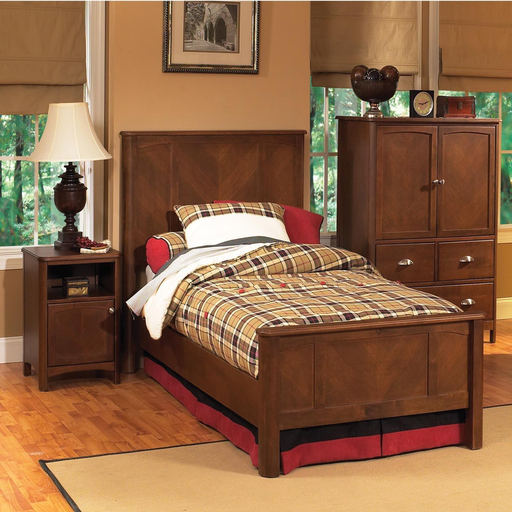

In [2]:
dataset = datasets.load_dataset('danjacobellis/scene_parse_150', split='validation')
img = dataset[1883]['image']
crop = img.resize((512, 512), resample=PIL.Image.Resampling.LANCZOS)
crop

## Sensor side — FRAPPE encoder

The encoder is intentionally tiny: a handful of strided convolutions, one per scale. Visualizing the first few filters makes that asymmetry concrete — the heavy lifting (matched decoder + transcoder) happens off-sensor.

In [3]:
config, weights, _ = frappe_load_from_hub()
n_trained = 12
merged = load_progressive_model(weights, config, n_trained, device)

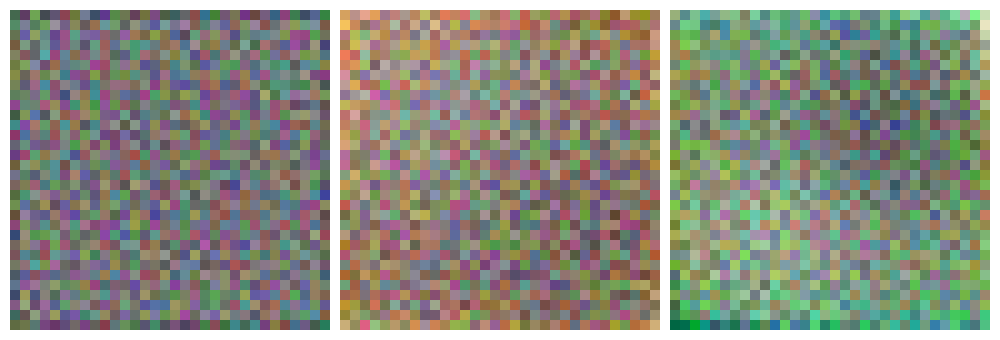

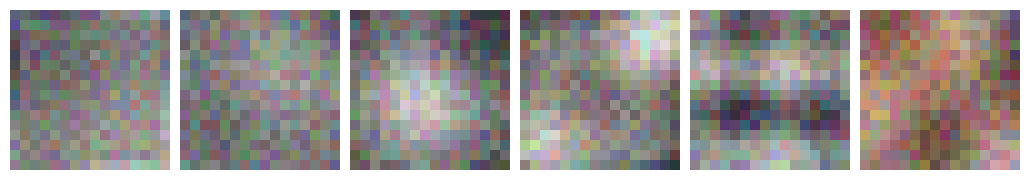

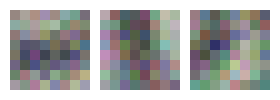

In [4]:
n_show = 12
filter_groups = []
for s, (ps_s, start, end) in enumerate(merged.scale_groups):
    if start >= n_show:
        break
    take = min(end, n_show) - start
    filter_groups.append((
        ps_s,
        merged.encoders[s][0].weight.data.cpu()[:take],
        merged.encoders[s][0].bias.data.cpu()[:take],
    ))

display_scale = 10
for ps_s, filters, biases in filter_groups:
    grid = make_filter_grid(filters, biases, filters.shape[0], layout=(1, filters.shape[0]))
    w_px, h_px = grid.shape[2] * display_scale, grid.shape[1] * display_scale
    display(to_pil_image(grid).resize((w_px, h_px), resample=PIL.Image.Resampling.NEAREST))

The FRAPPE encoder operates in linear light when `config.linear_input` is set, so the sRGB input is linearized first. Encoder output is clamped/rounded to int8 — this is what the lossless entropy coder would ship to the cloud.

In [5]:
x = pil_to_tensor(crop.convert('RGB')).to(torch.float).to(device).unsqueeze(0) / 127.5 - 1.0
x_in = srgb_to_linear(x) if getattr(config, 'linear_input', False) else x

with torch.inference_mode():
    latents = merged.encode(x_in)
    latents_q = [z.clamp(-127, 127).round() for z in latents]

[tuple(z.shape) for z in latents_q]

[(1, 3, 16, 16), (1, 6, 32, 32), (1, 3, 64, 64)]

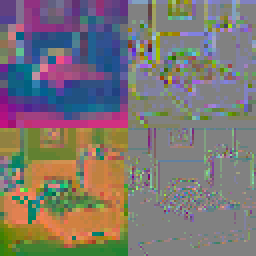

In [6]:
tiles = [
    to_pil_image(16*latents_q[0][0]+127).resize((128, 128), resample=PIL.Image.Resampling.NEAREST),
    to_pil_image(32*latents_q[1][0][:3]+127).resize((128, 128), resample=PIL.Image.Resampling.NEAREST),
    to_pil_image(16*latents_q[1][0][3:]+127).resize((128, 128), resample=PIL.Image.Resampling.NEAREST),
    to_pil_image(32*latents_q[2][0]+127).resize((128, 128), resample=PIL.Image.Resampling.NEAREST),
]
grid = PIL.Image.new('RGB', (256, 256))
for i, tile in enumerate(tiles):
    grid.paste(tile.convert('RGB'), (128 * (i % 2), 128 * (i // 2)))
grid

## Cloud side — FRAPPE decoder then JPEG transcode

The FRAPPE decoder reconstructs RGB from the quantized latents. From here the cloud rewrites the signal as a standard JPEG so the rest of the world can decode it with off-the-shelf libjpeg.

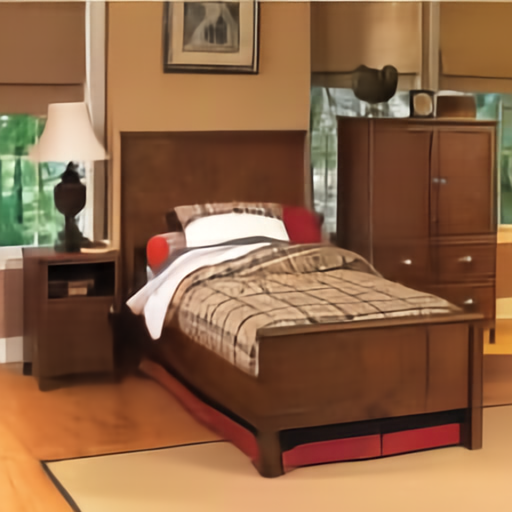

In [7]:
with torch.inference_mode():
    xhat = merged.decode(latents_q).clamp(-1, 1)

recon = to_pil_image((xhat[0] / 2 + 0.5).cpu().clamp(0, 1))
recon

The published bundle holds one shared `(ForwardTransform, InverseTransform)` pair plus K=3 qtables, jointly trained on LSDIR under a shared R-D loss with three lambdas. We pick one operating point and pull out the matching qtable.

In [8]:
bundle = load_from_hub()
k = 0
lam = bundle.lambdas[k]
qtable = bundle.qtables[k]
bundle.lambdas, qtable.shape, qtable.dtype

([0.65, 0.4, 0.22], torch.Size([3, 8, 8]), torch.int32)

### ForwardTransform — learned RGB → codec

`bundle.fwd` is a small 3×3 conv + softsign companding + per-channel affine, trained from algebraic-identity init. The output is intentionally near `[0, 255]` so libjpeg sees something it considers a YCbCr image — but it is **not** JFIF YCbCr. The conv has no inductive bias toward luma/chroma; the three channels are whatever the joint R-D objective made them be.

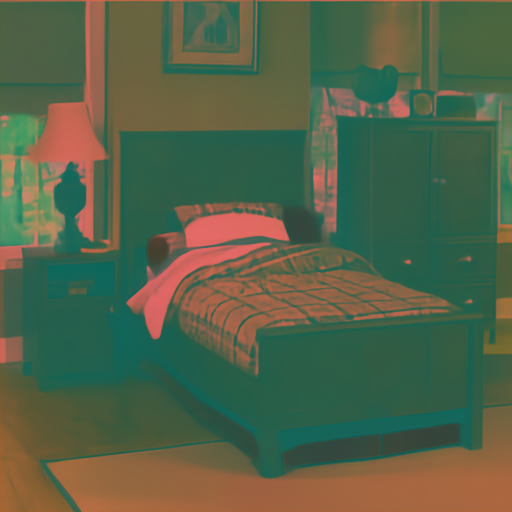

In [9]:
x_recon = pil_to_tensor(recon.convert('RGB')).float().unsqueeze(0)
with torch.inference_mode():
    codec_input_float = bundle.fwd(x_recon).squeeze(0)
codec_input = codec_input_float.clamp(0, 255).round().to(torch.uint8)
to_pil_image(codec_input)

### Inside libjpeg — DCT and quantization

Reproducing the libjpeg distortion chain in torch so the intermediates are addressable. `batch_dct` is an 8×8 block DCT vendored from torchjpeg — same normalization as JPEG.

In [10]:
x_codec = codec_input.float().unsqueeze(0) - 128.0
with torch.inference_mode():
    dct = batch_dct(x_codec)
dct.shape

torch.Size([1, 3, 512, 512])

Re-tile so each pixel corresponds to one DCT frequency across the image — DC in the upper-left of each channel, highest spatial frequencies toward the bottom-right.

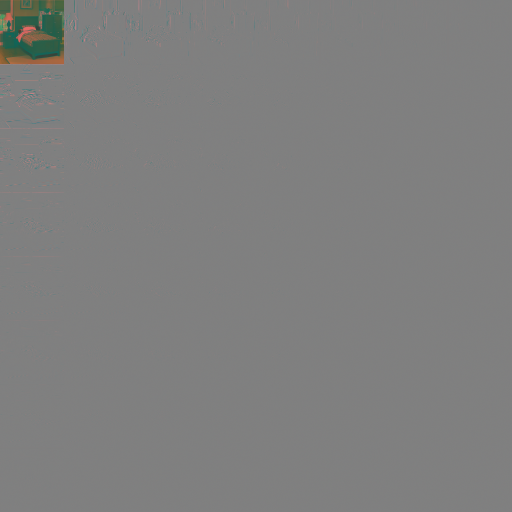

In [11]:
pattern = 'b c (bh i) (bw j) -> b c (i bh) (j bw)'
dct_freq_major = rearrange(dct, pattern, i=8, j=8)

disp = (dct_freq_major[0] / 8.0).clamp(-127, 127) + 128
to_pil_image(disp.to(torch.uint8))

AC magnitudes shrink fast with frequency. Normalizing each 64×64 frequency tile by its own std (DC tile left unscaled) makes the AC structure visible.

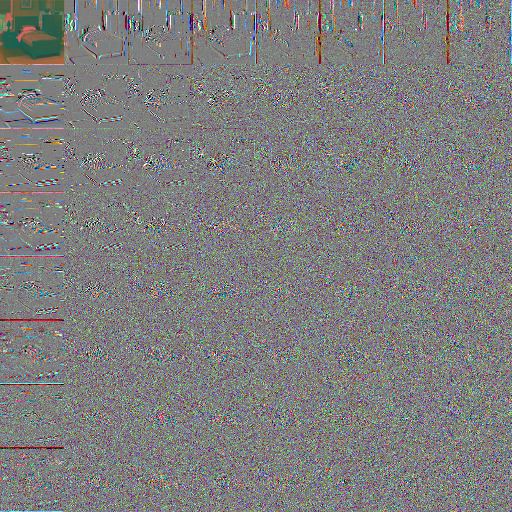

In [12]:
sigma = rearrange(dct_freq_major, 'b c (i bh) (j bw) -> b c i j bh bw', bh=64, bw=64).std(dim=(-2, -1))
sigma_map = repeat(sigma, 'b c i j -> b c (i bh) (j bw)', bh=64, bw=64)

disp = ((dct_freq_major / (3 * sigma_map)).clamp(-1, 1) * 127.5 + 127.5)[0]
disp[:, :64, :64] = (dct_freq_major[0, :, :64, :64] / 8.0).clamp(-127, 127) + 128
to_pil_image(disp.to(torch.uint8))

Per-channel qtable (3, 8, 8 int32). All three are learned jointly with the color transform — there is no luma/chroma asymmetry baked in. DC is in the upper-left of each 8×8 block.

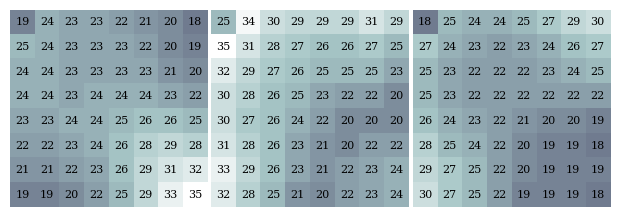

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(6, 2))
vmax = qtable.max().item()
for c, ax in enumerate(axes):
    ax.imshow(qtable[c].numpy(), cmap='bone', vmin=1, vmax=vmax, interpolation='nearest')
    for i in range(8):
        for j in range(8):
            ax.text(j, i, f'{qtable[c, i, j].item()}', ha='center', va='center',
                    color='black', fontsize=8, family='serif')
    ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02)
plt.show()

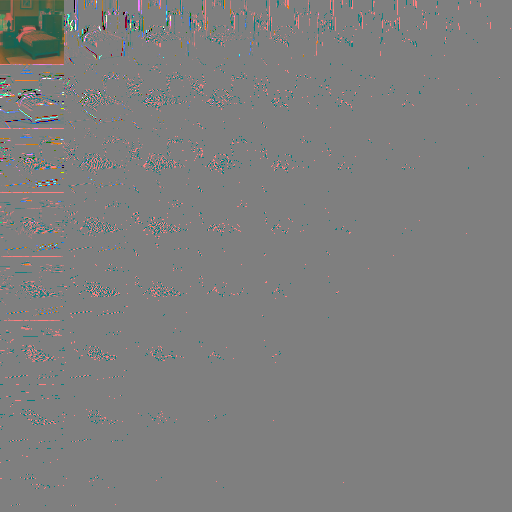

In [14]:
q_map = qtable.float().repeat(1, dct.shape[2] // 8, dct.shape[3] // 8).unsqueeze(0)
dct_quant = (dct / q_map).round() * q_map
dct_quant_freq_major = rearrange(dct_quant, pattern, i=8, j=8)

disp = ((dct_quant_freq_major / (3 * sigma_map)).clamp(-1, 1) * 127.5 + 127.5)[0]
disp[:, :64, :64] = (dct_quant_freq_major[0, :, :64, :64] / 8.0).clamp(-127, 127) + 128
to_pil_image(disp.to(torch.uint8))

### Actual JPEG round-trip

Hand the codec-domain tensor + qtable to `jpeg_codec.encode`. `subsampling=0` keeps libjpeg in 4:4:4 mode — these channels aren't really chroma, so any subsampling would silently degrade them.

`jpeg_codec.decode` uses `Image.draft('YCbCr', size)` to read the samples back without applying libjpeg's YCbCr→RGB matrix. So `codec_decoded` lives in the same domain as `codec_input` did before quantization.

In [15]:
jpeg_bytes = jpeg_codec.encode(codec_input, qtable, subsampling=0)
codec_decoded = jpeg_codec.decode(jpeg_bytes)

bpp = 8 * len(jpeg_bytes) / (codec_input.shape[-1] * codec_input.shape[-2])
len(jpeg_bytes), f'{bpp:.3f} bpp'

(21255, '0.649 bpp')

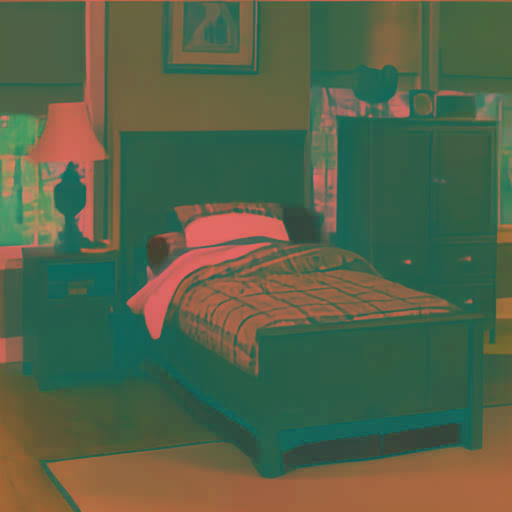

In [16]:
to_pil_image(codec_decoded)

## Consumer side — InverseTransform

The cloud emitted a normal JPEG file. A consumer (training-data loader, smartphone, video player) runs libjpeg + a single 3×3 conv to recover RGB. This is the only learned component on the consumer side, so it has to be cheap.

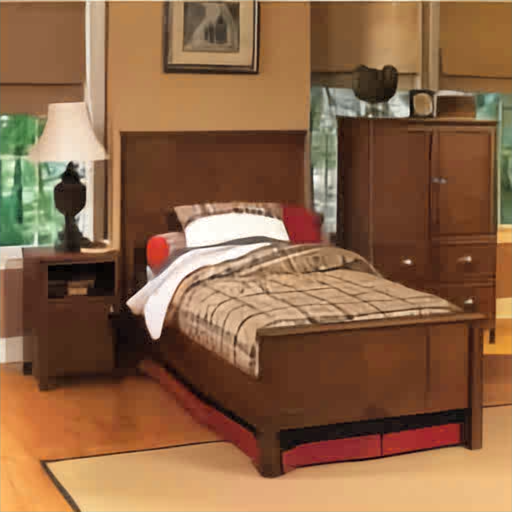

In [17]:
z = codec_decoded.float().unsqueeze(0)
with torch.inference_mode():
    final_recon_float = bundle.inv(z).squeeze(0)
final_recon = final_recon_float.clamp(0, 255).round().to(torch.uint8)
to_pil_image(final_recon)

PSNR of the full pipeline vs the FRAPPE-decoded `recon` (i.e. the loss attributable only to the JPEG transcode), and vs the original `crop` (the end-to-end loss including the FRAPPE round-trip).

In [18]:
def psnr(a_uint8, b_uint8):
    mse = ((a_uint8.float() - b_uint8.float()) ** 2).mean().item()
    return 10 * math.log10(255.0 ** 2 / max(mse, 1e-12))

recon_uint8 = pil_to_tensor(recon.convert('RGB'))
crop_uint8 = pil_to_tensor(crop.convert('RGB'))

{
    'transcode_only (final_recon vs recon)': psnr(final_recon, recon_uint8),
    'end_to_end   (final_recon vs crop)':    psnr(final_recon, crop_uint8),
    'frappe_only  (recon vs crop)':          psnr(recon_uint8, crop_uint8),
    'bpp_jpeg':                              bpp,
    'lambda':                                lam,
}

{'transcode_only (final_recon vs recon)': 37.34432797084724,
 'end_to_end   (final_recon vs crop)': 24.096047303853364,
 'frappe_only  (recon vs crop)': 24.28920537515177,
 'bpp_jpeg': 0.648651123046875,
 'lambda': 0.65}

## Downstream — semantic segmentation

Run the deployment seg teacher (`smp-hub/upernet-convnext-tiny`, 150-class ADE20K head — the same model used to source FT pseudolabels in `recipes.md` §3) on `final_recon` on CPU. Display the per-pixel argmax (uint8 class IDs in `[0, 149]`) as a plain grayscale image — no colormap.

In [19]:
import segmentation_models_pytorch as smp

seg_teacher = smp.from_pretrained('smp-hub/upernet-convnext-tiny').eval()
for p in seg_teacher.parameters():
    p.requires_grad_(False)

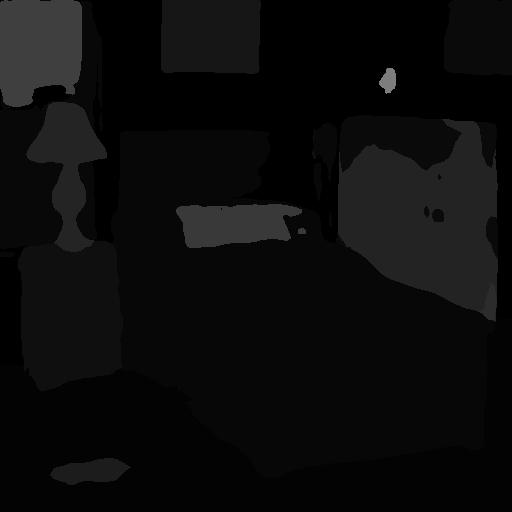

In [20]:
IN1K_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
IN1K_STD = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

x_norm = ((final_recon.float() / 255.0 - IN1K_MEAN) / IN1K_STD).unsqueeze(0)
with torch.inference_mode():
    logits = seg_teacher(x_norm)
pred = logits.argmax(dim=1).squeeze(0).to(torch.uint8)
to_pil_image(pred)

### Per-image pixel accuracy

mIoU needs many images to be meaningful (most classes are absent on any single frame), so for the per-image visualization use the simpler pixel-accuracy metric: fraction of *annotated* pixels in the GT for which the teacher's argmax matches the GT class. The GT annotation uses the standard ADE20K convention from `danjacobellis/scene_parse_150` (raw value 0 = "unannotated"; subtract 1 so class indices are `0..149` and unannotated pixels are excluded from the denominator).

In [21]:
ann = dataset[1883]['annotation']
gt = ann.resize((512, 512), resample=PIL.Image.Resampling.NEAREST)
gt_t = pil_to_tensor(gt).squeeze(0).to(torch.int16) - 1

mask = gt_t >= 0
acc = (pred[mask].to(torch.int16) == gt_t[mask]).float().mean().item()

{
    'pixel_accuracy_vs_GT': acc,
    'annotated_frac':       mask.float().mean().item(),
    'gt_classes_present':   torch.unique(gt_t[mask]).numel(),
}

{'pixel_accuracy_vs_GT': 0.6632401347160339,
 'annotated_frac': 0.9904556274414062,
 'gt_classes_present': 14}